# DataPulse — Exploratory Data Analysis (EDA)
### CodeAlpha Data Science Internship | Task 2
**Dataset:** Flipkart Laptop Listings (Scraped & Cleaned)  
**Goal:** Uncover pricing trends, brand performance, rating patterns, and discount insights

---

## Step 1 — Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load Dataset

In [29]:
# Load the cleaned dataset
# Update the path if your file is in a different location
df = pd.read_csv('../data/flipkart_laptops_cleaned.csv')

print(f'Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded!
Shape: 793 rows × 8 columns


,Brand,Product Name,Selling Price (INR),Original Price (INR),Discount (%),Rating,Number of Ratings,Number of Reviews
0,Acer,Acer TravelLite AMD Ryzen 5 7430U - (16 GB/512...,44990,50000.0,10.0,3.8,125.0,11.0
1,HP,HP Victus Intel Core i5 13th Gen 13420H - (16 ...,72990,81201.0,10.0,4.3,733.0,50.0
2,ASUS,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,38990,50990.0,23.0,4.3,1532.0,77.0
3,Lenovo,Lenovo IdeaPad Slim 5 WUXGA OLED Full Metal Bo...,59990,97290.0,38.0,4.4,85.0,11.0
4,Lenovo,Lenovo IdeaPad Slim 3 AMD Ryzen 7 Octa Core 88...,70990,94890.0,25.0,4.4,78.0,7.0
5,ASUS,ASUS Chromebook CX14 Intel Celeron Dual Core N...,14990,23990.0,37.0,3.8,229.0,15.0
6,ASUS,ASUS Vivobook Go 15 (2025) with Office 2024 + ...,37990,NaN,NaN,4.1,89.0,8.0
7,ASUS,ASUS Vivobook Go 15 (2025) with Office 2024 + ...,42990,52990.0,18.0,4.3,1532.0,77.0
8,Acer,Acer Aspire Lite Intel Core i3 12th Gen 1215U ...,39990,55990.0,28.0,4.1,1054.0,84.0
9,HP,HP 15 with Backlit Keyboard & Office 2024 AMD ...,52990,60248.0,12.0,4.1,362.0,23.0


---
## Step 3 — Basic Data Overview

In [30]:
print('=' * 50)
print('📋DATASET INFO')
print('=' * 50)
df.info()

📋DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 793 non-null    str    
 1   Product Name          793 non-null    str    
 2   Selling Price (INR)   793 non-null    int64  
 3   Original Price (INR)  712 non-null    float64
 4   Discount (%)          699 non-null    float64
 5   Rating                626 non-null    float64
 6   Number of Ratings     626 non-null    float64
 7   Number of Reviews     626 non-null    float64
dtypes: float64(5), int64(1), str(2)
memory usage: 49.7 KB


In [31]:
print('=' * 50)
print('📊 STATISTICAL SUMMARY')
print('=' * 50)
df.describe().round(2)

📊 STATISTICAL SUMMARY


,Selling Price (INR),Original Price (INR),Discount (%),Rating,Number of Ratings,Number of Reviews
count,793.00,712.00,699.00,626.00,626.00,626.00
mean,90357.58,108347.82,21.35,4.21,990.12,71.87
std,70880.39,77714.52,11.90,0.42,2174.49,137.74
min,13990.00,16298.00,1.00,1.70,1.00,0.00
25%,48990.00,64961.00,11.00,4.10,21.00,2.00
50%,65990.00,85645.00,20.00,4.30,133.50,12.00
75%,104990.00,116992.25,30.00,4.40,866.00,76.75
max,524190.00,572317.00,57.00,5.00,18611.00,971.00


In [32]:
print('=' * 50)
print('❓ MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

print(f'\n🔢 Total unique brands: {df["Brand"].nunique()}')
print(f'💰 Price range: ₹{df["Selling Price (INR)"].min():,.0f} — ₹{df["Selling Price (INR)"].max():,.0f}')
print(f'⭐ Rating range: {df["Rating"].min()} — {df["Rating"].max()}')

❓ MISSING VALUES
                      Missing Count  Missing %
Brand                             0       0.00
Product Name                      0       0.00
Selling Price (INR)               0       0.00
Original Price (INR)             81      10.21
Discount (%)                     94      11.85
Rating                          167      21.06
Number of Ratings               167      21.06
Number of Reviews               167      21.06

🔢 Total unique brands: 12
💰 Price range: ₹13,990 — ₹524,190
⭐ Rating range: 1.7 — 5.0


---
## Step 4 — Brand Analysis

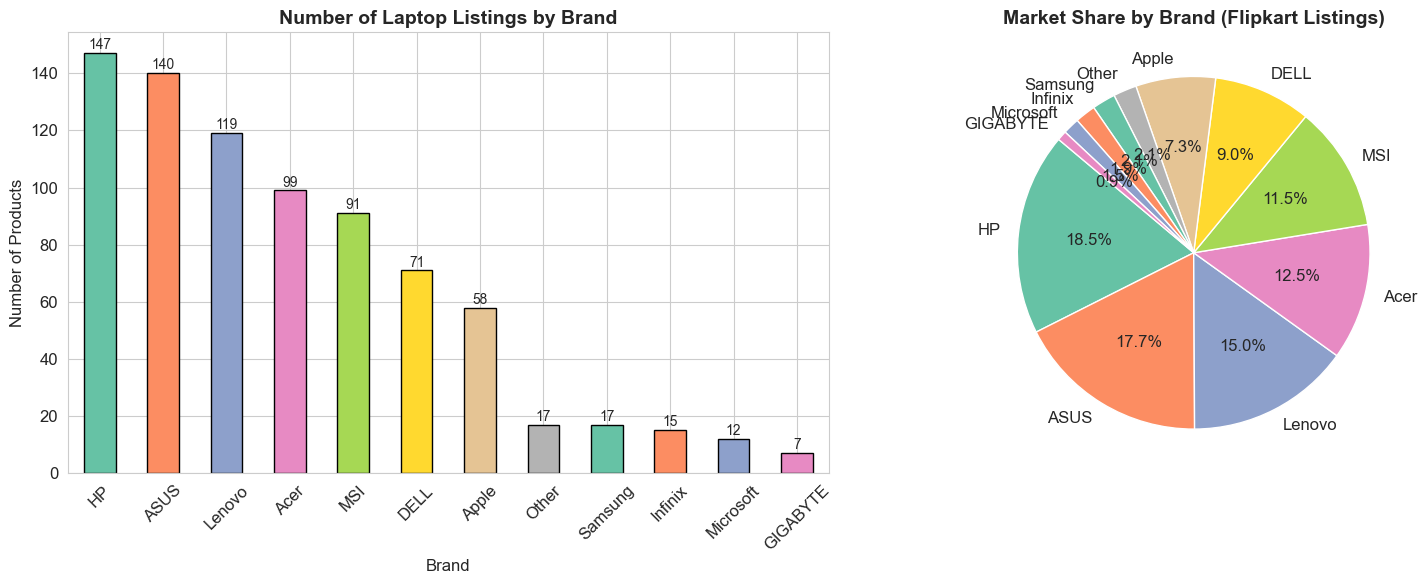


📌 Insight: ASUS and HP dominate Flipkart laptop listings.


In [33]:
# ---- 4A. Brand Distribution ----
brand_counts = df['Brand'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
brand_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(brand_counts)), edgecolor='black')
axes[0].set_title('Number of Laptop Listings by Brand', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Number of Products')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(brand_counts.values, labels=brand_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(brand_counts)), startangle=140)
axes[1].set_title('Market Share by Brand (Flipkart Listings)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/brand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: ASUS and HP dominate Flipkart laptop listings.')

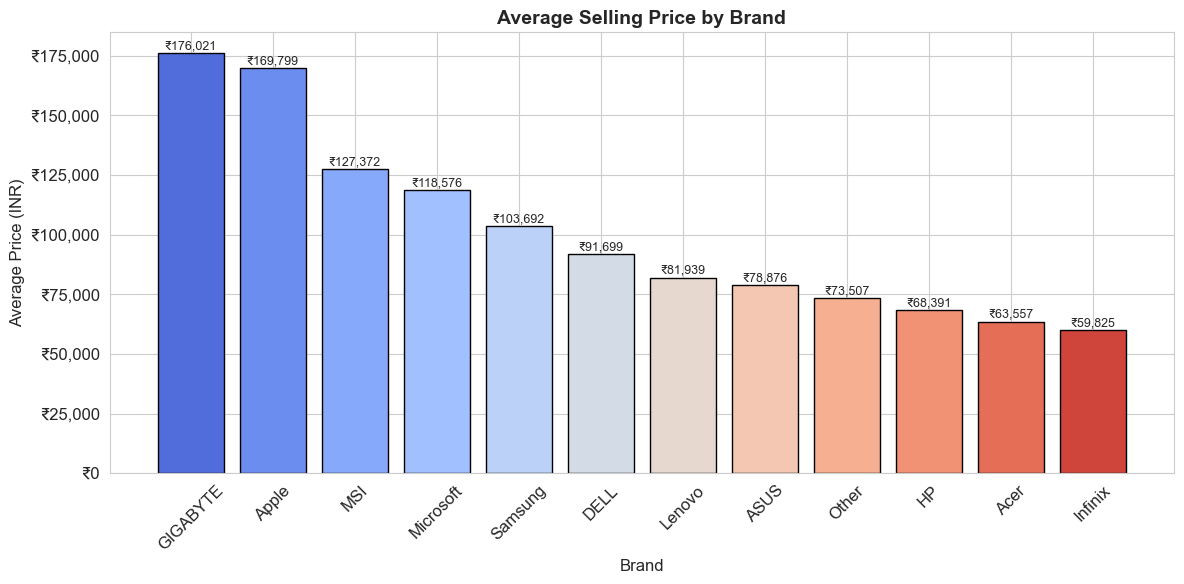


📌 Insight: Apple and MSI are the most premium brands. Acer and ASUS offer budget-friendly options.


In [34]:
# ---- 4B. Average Price Per Brand ----
brand_price = df.groupby('Brand')['Selling Price (INR)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(brand_price.index, brand_price.values,
               color=sns.color_palette('coolwarm', len(brand_price)), edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Average Selling Price by Brand', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.savefig('images/brand_avg_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Apple and MSI are the most premium brands. Acer and ASUS offer budget-friendly options.')

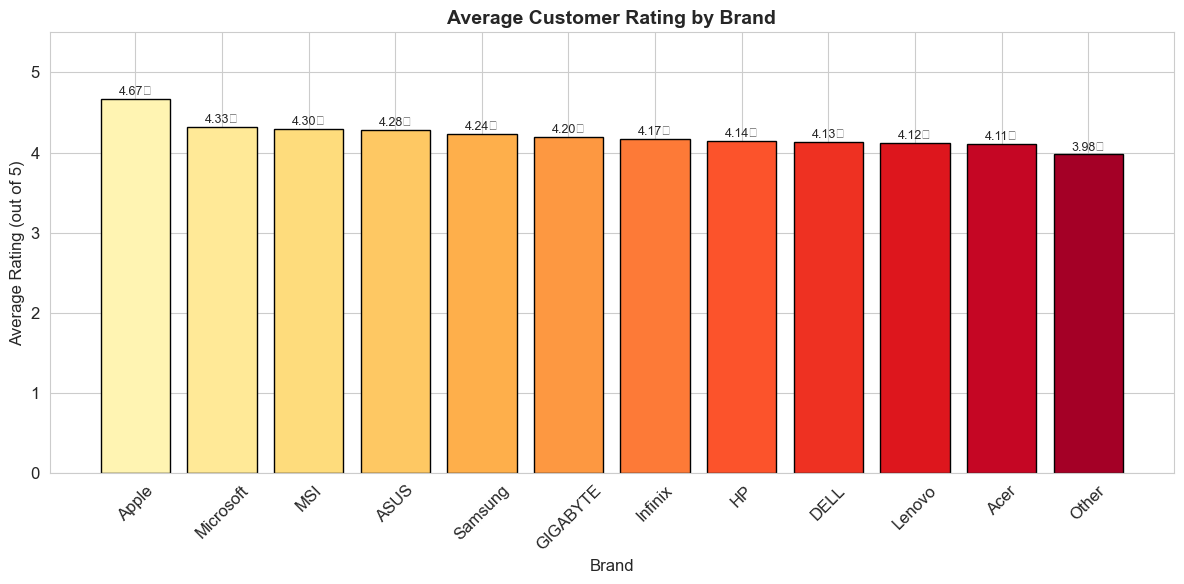


📌 Insight: Most brands maintain ratings between 4.0-4.5 showing overall good customer satisfaction.


In [35]:
# ---- 4C. Average Rating Per Brand ----
brand_rating = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(brand_rating.index, brand_rating.values,
               color=sns.color_palette('YlOrRd', len(brand_rating)), edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}⭐', ha='center', va='bottom', fontsize=9)

plt.title('Average Customer Rating by Brand', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Average Rating (out of 5)')
plt.ylim(0, 5.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/brand_avg_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Most brands maintain ratings between 4.0-4.5 showing overall good customer satisfaction.')

---
## Step 5 — Price Analysis

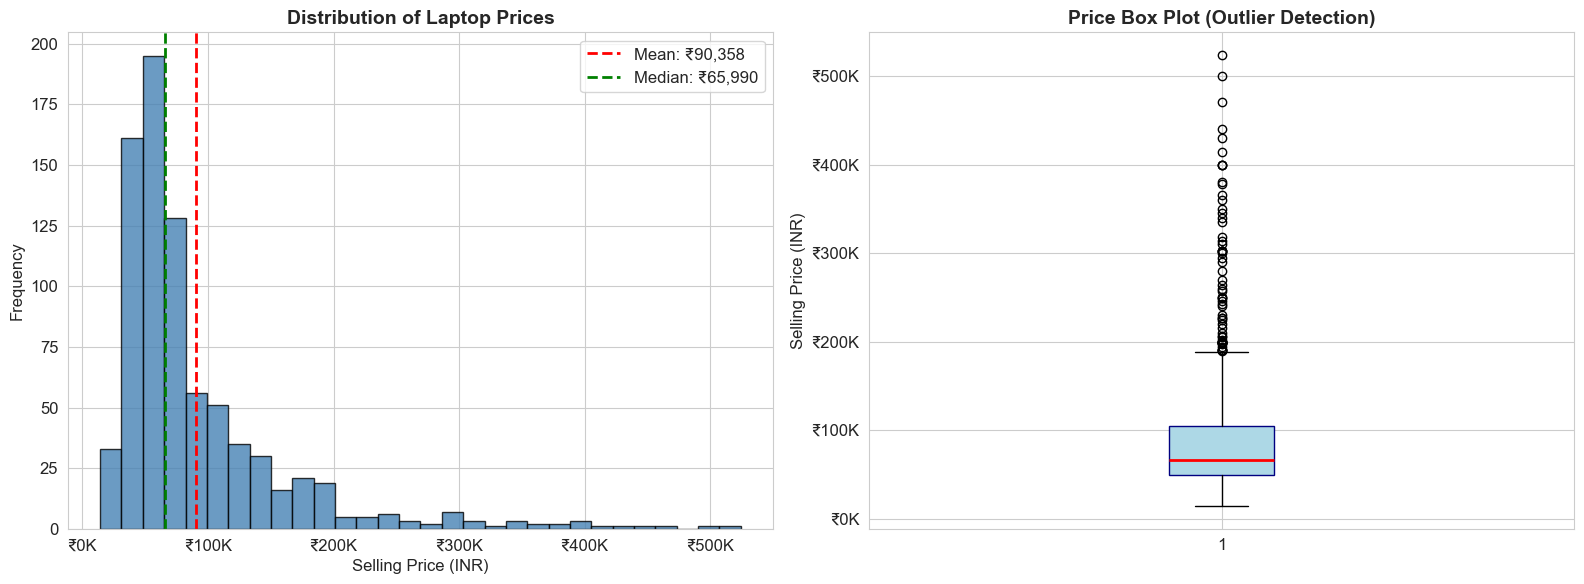


📌 Insight: Most laptops are priced between ₹30,000-₹80,000. The distribution is right-skewed indicating a few premium models.


In [36]:
# ---- 5A. Price Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['Selling Price (INR)'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['Selling Price (INR)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{df["Selling Price (INR)"].mean():,.0f}')
axes[0].axvline(df['Selling Price (INR)'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ₹{df["Selling Price (INR)"].median():,.0f}')
axes[0].set_title('Distribution of Laptop Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selling Price (INR)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Box plot
axes[1].boxplot(df['Selling Price (INR)'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price Box Plot (Outlier Detection)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Selling Price (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Most laptops are priced between ₹30,000-₹80,000. The distribution is right-skewed indicating a few premium models.')

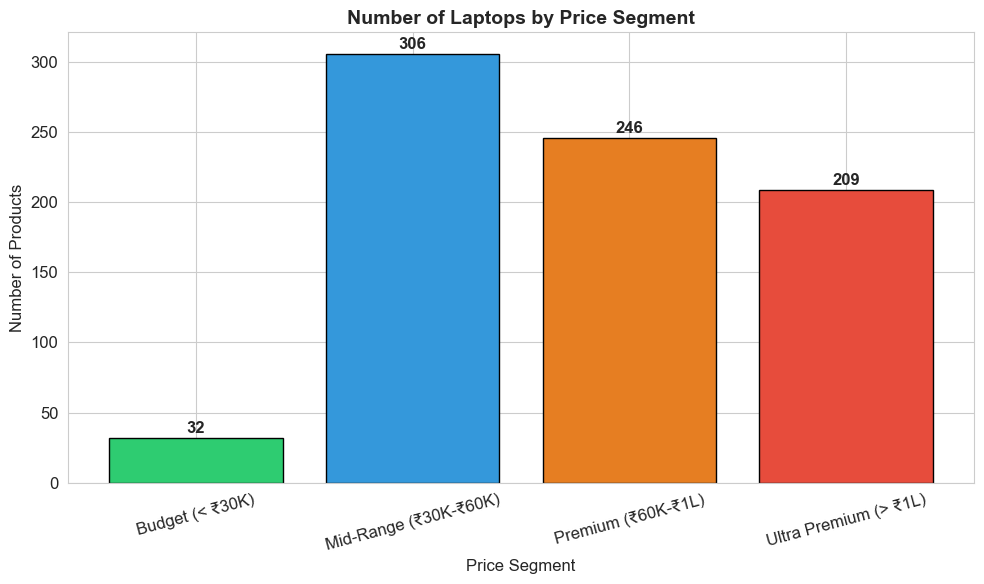


📌 Insight: Mid-range laptops dominate Flipkart listings showing strong demand in the ₹30K-₹60K segment.


In [37]:
# ---- 5B. Price Segment / Category ----
def price_segment(price):
    if pd.isna(price): return 'Unknown'
    elif price < 30000: return 'Budget (< ₹30K)'
    elif price < 60000: return 'Mid-Range (₹30K-₹60K)'
    elif price < 100000: return 'Premium (₹60K-₹1L)'
    else: return 'Ultra Premium (> ₹1L)'

df['Price Segment'] = df['Selling Price (INR)'].apply(price_segment)

segment_order = ['Budget (< ₹30K)', 'Mid-Range (₹30K-₹60K)', 'Premium (₹60K-₹1L)', 'Ultra Premium (> ₹1L)']
segment_counts = df['Price Segment'].value_counts().reindex(segment_order)

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
plt.figure(figsize=(10, 6))
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Number of Laptops by Price Segment', fontsize=14, fontweight='bold')
plt.xlabel('Price Segment')
plt.ylabel('Number of Products')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('images/price_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Mid-range laptops dominate Flipkart listings showing strong demand in the ₹30K-₹60K segment.')

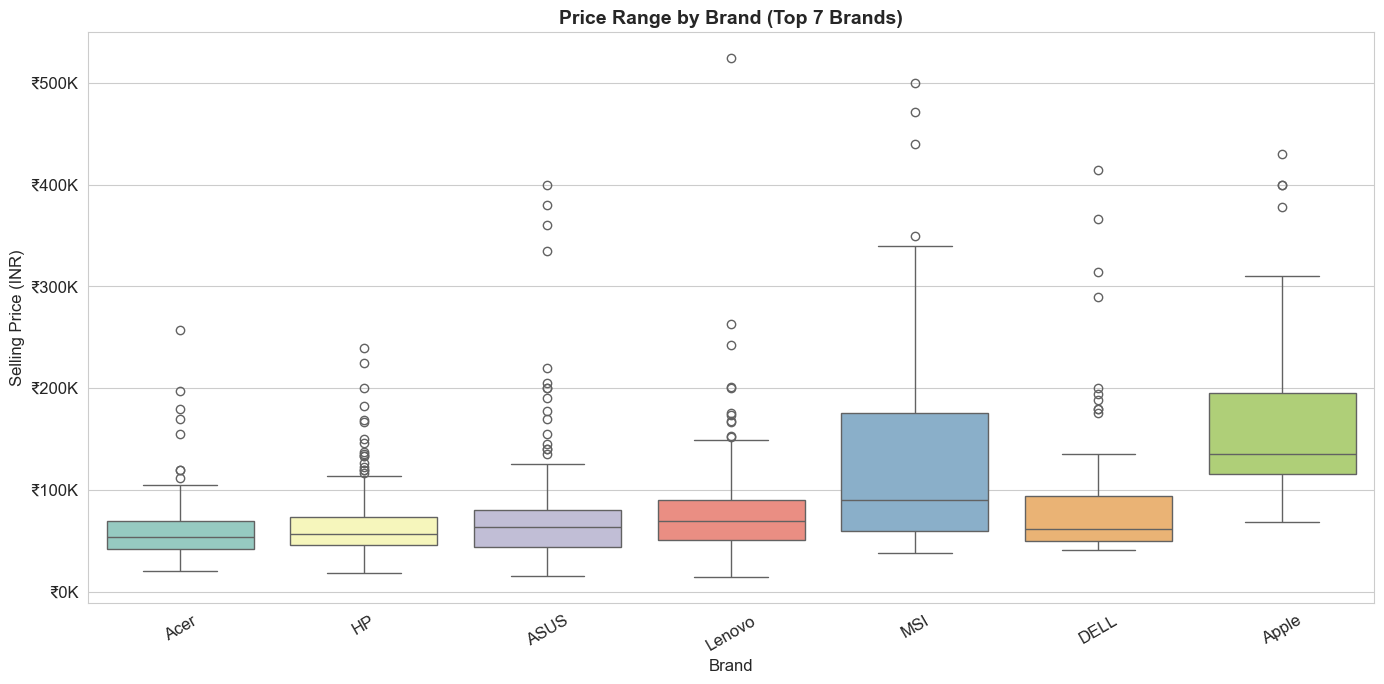


📌 Insight: Lenovo and HP have the widest price range — they serve both budget and premium segments.


In [38]:
# ---- 5C. Price Range Per Brand (Box Plot) ----
top_brands = df['Brand'].value_counts().head(7).index.tolist()
df_top = df[df['Brand'].isin(top_brands)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top, x='Brand', y='Selling Price (INR)', palette='Set3')
plt.title('Price Range by Brand (Top 7 Brands)', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Selling Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('images/price_range_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Lenovo and HP have the widest price range — they serve both budget and premium segments.')

---
## Step 6 — Discount Analysis

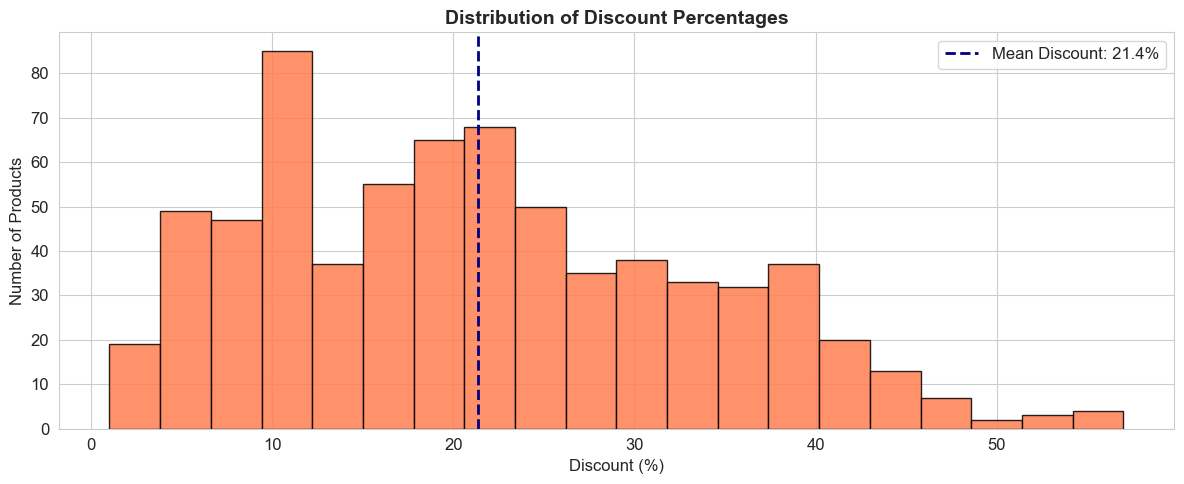


📌 Insight: Average discount is 21.4%. Most discounts fall between 10%-30%.


In [39]:
# ---- 6A. Discount Distribution ----
df_disc = df.dropna(subset=['Discount (%)'])

plt.figure(figsize=(12, 5))
plt.hist(df_disc['Discount (%)'], bins=20, color='coral', edgecolor='black', alpha=0.85)
plt.axvline(df_disc['Discount (%)'].mean(), color='navy', linestyle='--', linewidth=2,
            label=f'Mean Discount: {df_disc["Discount (%)"].mean():.1f}%')
plt.title('Distribution of Discount Percentages', fontsize=14, fontweight='bold')
plt.xlabel('Discount (%)')
plt.ylabel('Number of Products')
plt.legend()
plt.tight_layout()
plt.savefig('images/discount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 Insight: Average discount is {df_disc["Discount (%)"].mean():.1f}%. Most discounts fall between 10%-30%.')

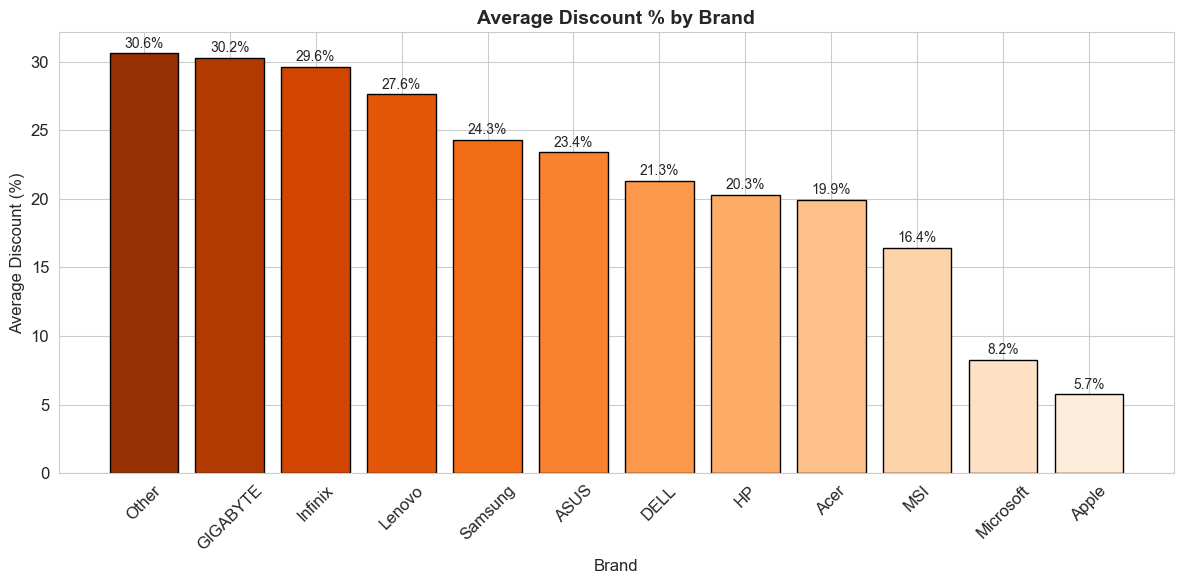


📌 Insight: Lenovo offers the highest average discounts, making it a value-for-money brand.


In [40]:
# ---- 6B. Average Discount Per Brand ----
brand_discount = df.groupby('Brand')['Discount (%)'].mean().sort_values(ascending=False).dropna()

plt.figure(figsize=(12, 6))
bars = plt.bar(brand_discount.index, brand_discount.values,
               color=sns.color_palette('Oranges_r', len(brand_discount)), edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Average Discount % by Brand', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Average Discount (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/discount_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Lenovo offers the highest average discounts, making it a value-for-money brand.')

---
## Step 7 — Rating Analysis

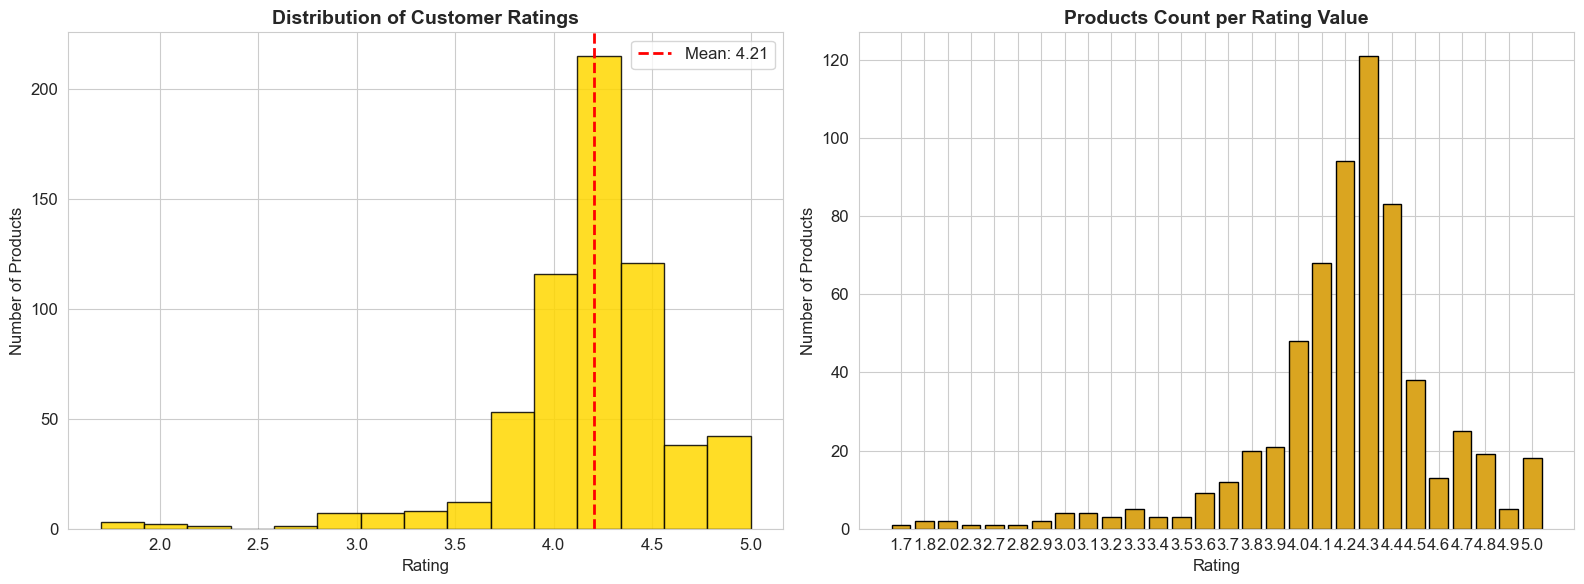


📌 Insight: Most laptops are rated between 4.0-4.5. Very few products fall below 3.5.


In [41]:
# ---- 7A. Rating Distribution ----
df_rated = df.dropna(subset=['Rating'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df_rated['Rating'], bins=15, color='gold', edgecolor='black', alpha=0.85)
axes[0].axvline(df_rated['Rating'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df_rated["Rating"].mean():.2f}')
axes[0].set_title('Distribution of Customer Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Products')
axes[0].legend()

# Count per rating value
rating_counts = df_rated['Rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
            color='goldenrod', edgecolor='black')
axes[1].set_title('Products Count per Rating Value', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.savefig('images/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 Insight: Most laptops are rated between 4.0-4.5. Very few products fall below 3.5.')

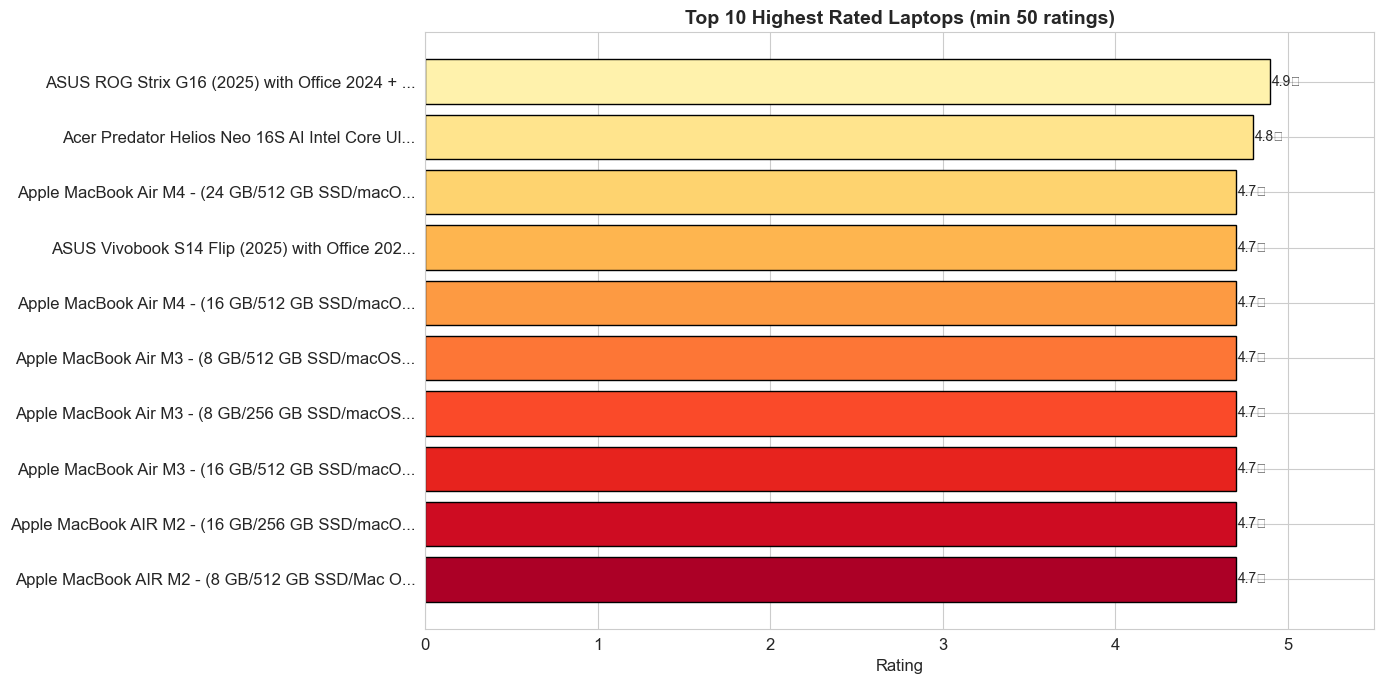


Top 10 Rated Products:
Brand  Selling Price (INR)  Rating  Number of Ratings
 ASUS               169990     4.9               52.0
 Acer               179999     4.8              107.0
Apple               132990     4.7             2624.0
 ASUS                63990     4.7               55.0
Apple               113990     4.7             2624.0
Apple               137990     4.7              483.0
Apple               126990     4.7              483.0
Apple               134900     4.7              483.0
Apple                85899     4.7            13195.0
Apple               104990     4.7             1930.0


In [42]:
# ---- 7B. Top 10 Highest Rated Products ----
top_rated = df.dropna(subset=['Rating', 'Number of Ratings'])
top_rated = top_rated[top_rated['Number of Ratings'] >= 50]  # Only products with 50+ ratings
top_rated = top_rated.nlargest(10, 'Rating')[['Brand', 'Product Name', 'Selling Price (INR)', 'Rating', 'Number of Ratings']]

# Truncate product names
top_rated['Short Name'] = top_rated['Product Name'].str[:45] + '...'

plt.figure(figsize=(14, 7))
bars = plt.barh(top_rated['Short Name'], top_rated['Rating'],
                color=sns.color_palette('YlOrRd', 10), edgecolor='black')
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}⭐', va='center', fontsize=10)

plt.title('Top 10 Highest Rated Laptops (min 50 ratings)', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.xlim(0, 5.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/top_rated_products.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Rated Products:')
print(top_rated[['Brand', 'Selling Price (INR)', 'Rating', 'Number of Ratings']].to_string(index=False))

---
## 🔗 Step 8 — Correlation Analysis

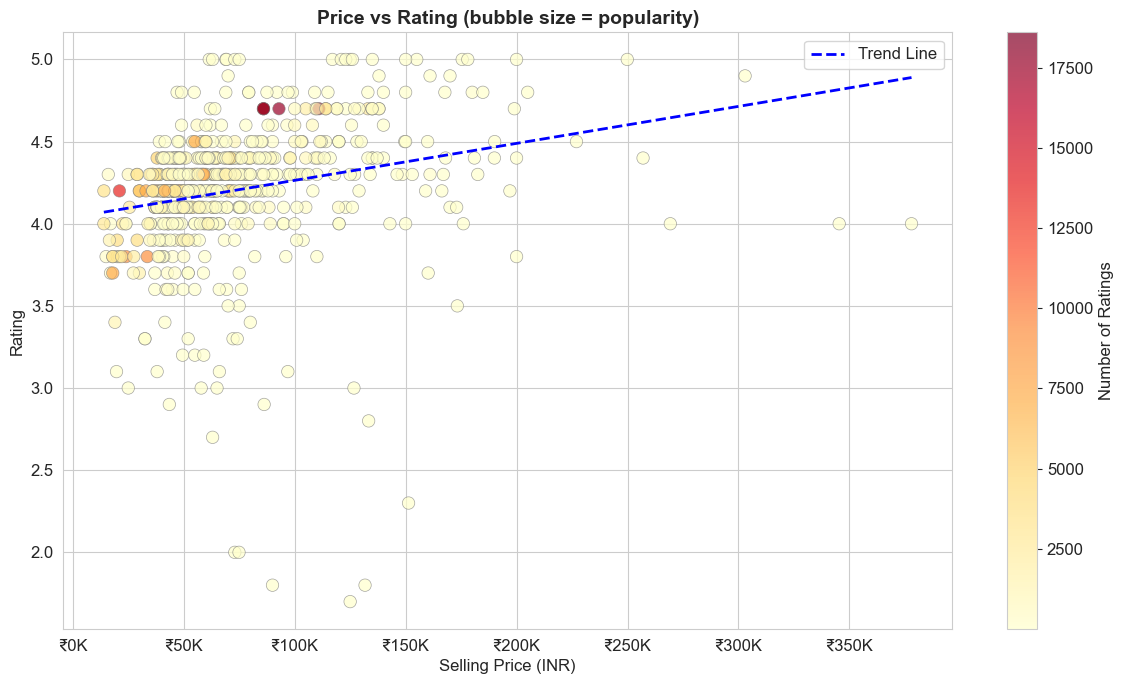


📌 Correlation between Price and Rating: 0.235
📌 Insight: Expensive does NOT always mean better rated. Budget laptops can also score high ratings.


In [43]:
# ---- 8A. Price vs Rating Scatter Plot ----
df_corr = df.dropna(subset=['Selling Price (INR)', 'Rating', 'Number of Ratings'])

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_corr['Selling Price (INR)'],
    df_corr['Rating'],
    c=df_corr['Number of Ratings'],
    cmap='YlOrRd',
    alpha=0.7,
    s=80,
    edgecolors='grey',
    linewidths=0.5
)
plt.colorbar(scatter, label='Number of Ratings')

# Trend line
z = np.polyfit(df_corr['Selling Price (INR)'], df_corr['Rating'], 1)
p = np.poly1d(z)
x_sorted = np.sort(df_corr['Selling Price (INR)'])
plt.plot(x_sorted, p(x_sorted), 'b--', linewidth=2, label='Trend Line')

plt.title('Price vs Rating (bubble size = popularity)', fontsize=14, fontweight='bold')
plt.xlabel('Selling Price (INR)')
plt.ylabel('Rating')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.legend()
plt.tight_layout()
plt.savefig('images/price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df_corr['Selling Price (INR)'].corr(df_corr['Rating'])
print(f'\n📌 Correlation between Price and Rating: {corr:.3f}')
print('📌 Insight: Expensive does NOT always mean better rated. Budget laptops can also score high ratings.')

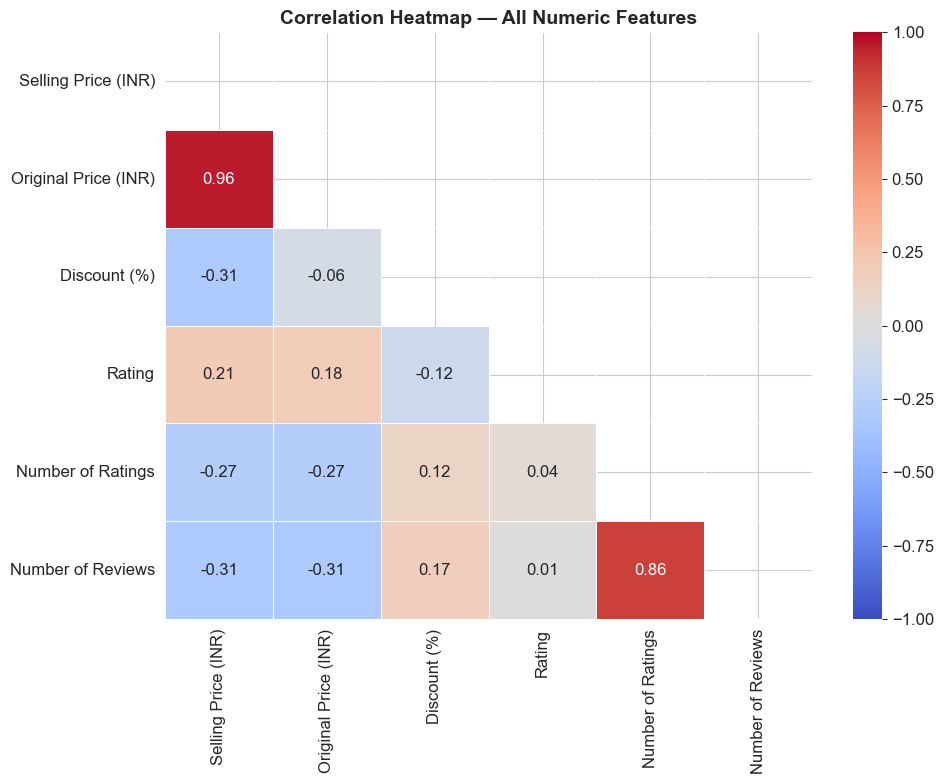


📌 Insight: Number of Ratings and Number of Reviews are highly correlated (expected).
📌 Discount % has a low correlation with Rating — heavy discounts do not guarantee better reviews.


In [44]:
# ---- 8B. Correlation Heatmap ----
numeric_cols = ['Selling Price (INR)', 'Original Price (INR)', 'Discount (%)', 
                'Rating', 'Number of Ratings', 'Number of Reviews']
df_numeric = df[numeric_cols].dropna()

corr_matrix = df_numeric.corr().round(2)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 12})
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Number of Ratings and Number of Reviews are highly correlated (expected).')
print('📌 Discount % has a low correlation with Rating — heavy discounts do not guarantee better reviews.')

---
## Step 9 — Top Products Analysis

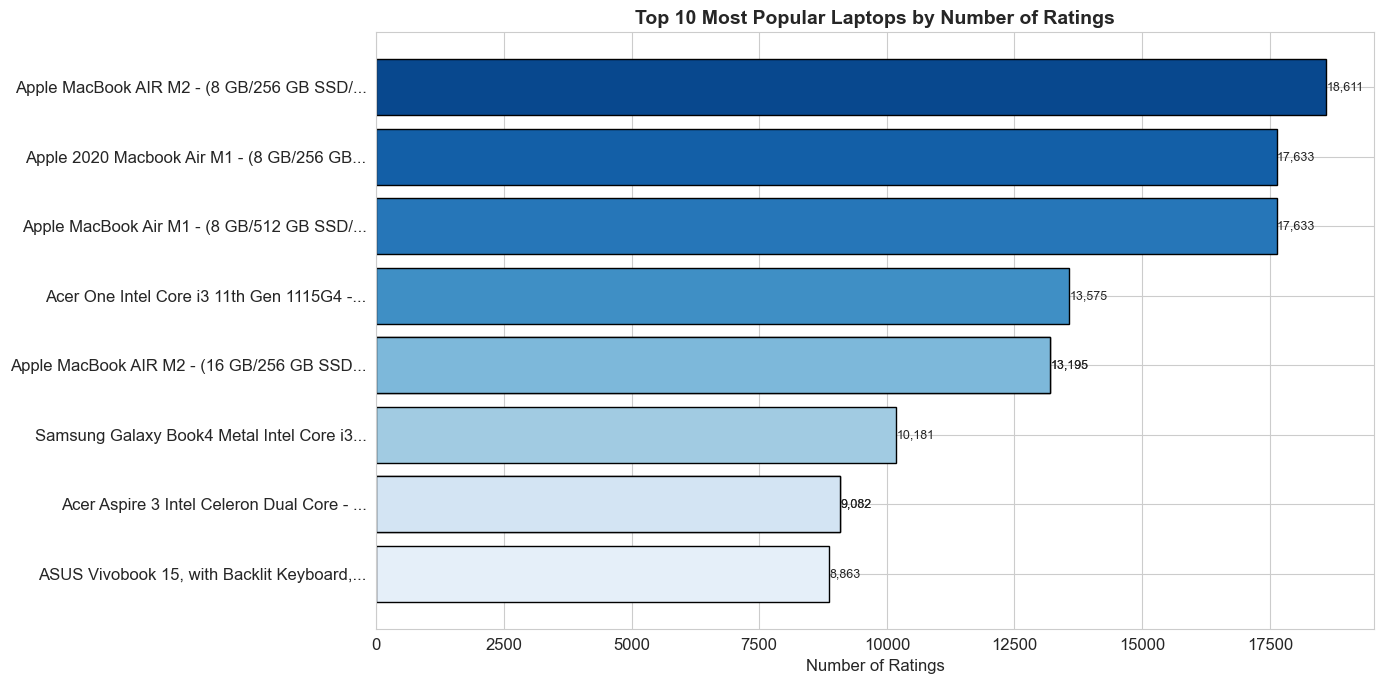

In [45]:
# ---- 9A. Top 10 Most Popular (by Number of Ratings) ----
most_popular = df.dropna(subset=['Number of Ratings']).nlargest(10, 'Number of Ratings')
most_popular['Short Name'] = most_popular['Product Name'].str[:40] + '...'

plt.figure(figsize=(14, 7))
bars = plt.barh(most_popular['Short Name'], most_popular['Number of Ratings'],
                color=sns.color_palette('Blues_r', 10), edgecolor='black')
for bar in bars:
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)

plt.title('Top 10 Most Popular Laptops by Number of Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/most_popular_products.png', dpi=150, bbox_inches='tight')
plt.show()

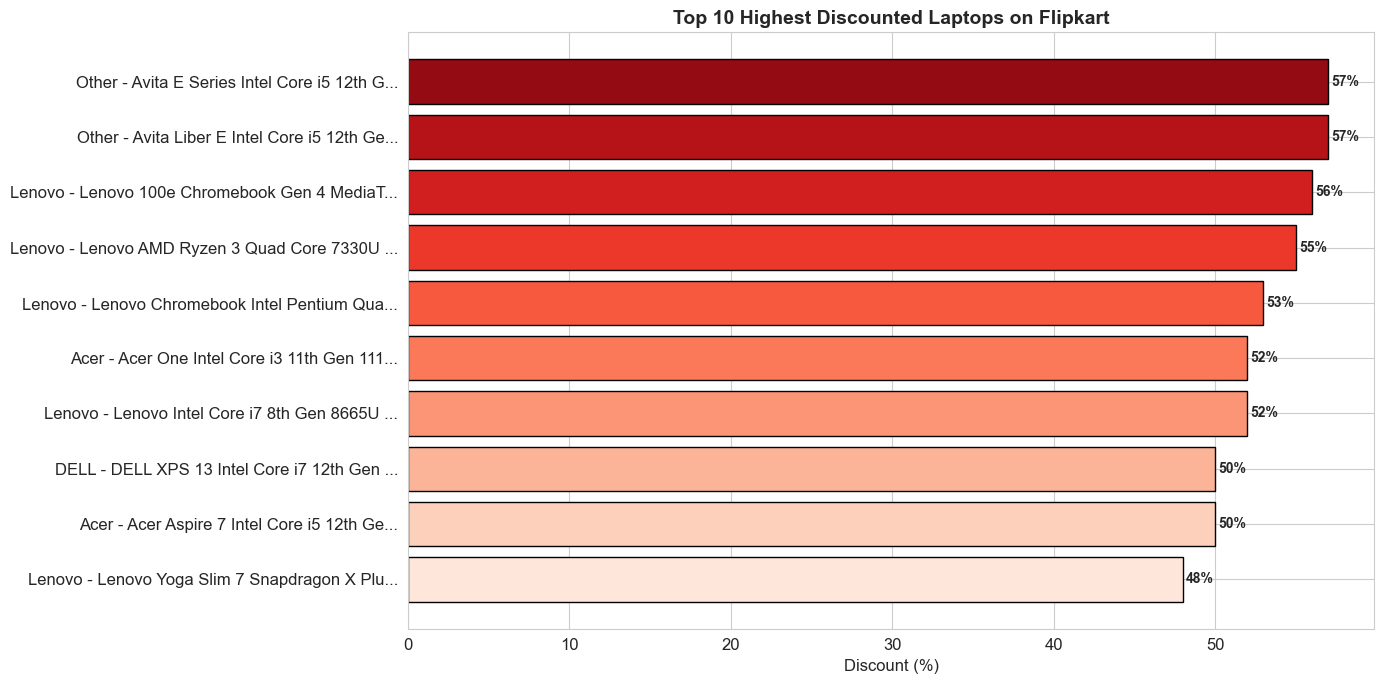

In [46]:
# ---- 9B. Top 10 Highest Discounted Products ----
most_discounted = df.dropna(subset=['Discount (%)']).nlargest(10, 'Discount (%)')
most_discounted['Short Name'] = most_discounted['Brand'] + ' - ' + most_discounted['Product Name'].str[:35] + '...'

plt.figure(figsize=(14, 7))
bars = plt.barh(most_discounted['Short Name'], most_discounted['Discount (%)'],
                color=sns.color_palette('Reds_r', 10), edgecolor='black')
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}%', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Highest Discounted Laptops on Flipkart', fontsize=14, fontweight='bold')
plt.xlabel('Discount (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/most_discounted_products.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 10 — Key Insights Summary

In [47]:
print('=' * 60)
print('       📊 EDA SUMMARY — KEY INSIGHTS')
print('=' * 60)

print(f'''
📦 DATASET
   • Total Products Analyzed  : {len(df)}
   • Total Brands             : {df['Brand'].nunique()}
   • Most Listed Brand        : {df['Brand'].value_counts().index[0]} ({df['Brand'].value_counts().values[0]} products)

💰 PRICING
   • Cheapest Laptop          : ₹{df['Selling Price (INR)'].min():,.0f}
   • Most Expensive Laptop    : ₹{df['Selling Price (INR)'].max():,.0f}
   • Average Price            : ₹{df['Selling Price (INR)'].mean():,.0f}
   • Median Price             : ₹{df['Selling Price (INR)'].median():,.0f}
   • Most Popular Segment     : {df['Price Segment'].value_counts().index[0]}

🏷️ DISCOUNTS
   • Average Discount         : {df['Discount (%)'].mean():.1f}%
   • Maximum Discount         : {df['Discount (%)'].max():.0f}%
   • Highest Discounting Brand: {df.groupby('Brand')['Discount (%)'].mean().idxmax()}

⭐ RATINGS
   • Average Rating           : {df['Rating'].mean():.2f} / 5
   • Highest Rated Brand      : {df.groupby('Brand')['Rating'].mean().idxmax()}
   • Price-Rating Correlation : {df['Selling Price (INR)'].corr(df['Rating']):.3f} (weak)
''')
print('=' * 60)

       📊 EDA SUMMARY — KEY INSIGHTS

📦 DATASET
   • Total Products Analyzed  : 793
   • Total Brands             : 12
   • Most Listed Brand        : HP (147 products)

💰 PRICING
   • Cheapest Laptop          : ₹13,990
   • Most Expensive Laptop    : ₹524,190
   • Average Price            : ₹90,358
   • Median Price             : ₹65,990
   • Most Popular Segment     : Mid-Range (₹30K-₹60K)

🏷️ DISCOUNTS
   • Average Discount         : 21.4%
   • Maximum Discount         : 57%
   • Highest Discounting Brand: Other

⭐ RATINGS
   • Average Rating           : 4.21 / 5
   • Highest Rated Brand      : Apple
   • Price-Rating Correlation : 0.235 (weak)



In [48]:
# Save final dataset with new columns added during EDA
df.to_csv('flipkart_laptops_eda.csv', index=False)
print('✅ Updated dataset saved as flipkart_laptops_eda.csv')

✅ Updated dataset saved as flipkart_laptops_eda.csv
